# Assignment 1
## Uncertainty and Sentiment in ARK Company Filings
FRE-GY 7871 A, Fall 2026. The analysis follows the current assignment brief. The instructor supplied data acquisition; the analysis additions and AI assistance are disclosed in `AI_USE.md`.

This is a retrospective event study, not an out-of-sample investment strategy. The complete specification and declared sensitivities are in [METHODOLOGY.md](METHODOLOGY.md).

## Reproduction
Run scripts `00` through `03`, then `05_get_price_actions.py` first. The downloads remain local and are excluded from Git. This notebook executes the analysis from those inputs, including text parsing, share recovery, exact-sample TF-IDF, all regressions and figures. A cached text matrix accelerates reruns; `build_text_data(force=True)` rebuilds it from the original HTML.

In [1]:
from pathlib import Path
import os, sys, runpy, json, subprocess
import pandas as pd
from IPython.display import display, Markdown, Image
ROOT=Path.cwd()
assert (ROOT/'src/config.py').exists(), 'Run the notebook from the repository root.'
os.environ['MPLCONFIGDIR']=str(ROOT/'outputs/mpl_cache')
sys.path.insert(0,str(ROOT))
RESULTS=ROOT/'outputs/analysis'
pd.set_option('display.max_rows',100)
pd.set_option('display.max_columns',30)
pd.set_option('display.float_format',lambda x:f'{x:.4f}')
def show_table(frame):
    labels={'measure':'Language measure','control_set':'Controls','beta':'Estimated coefficient',
            'se':'Standard error','t':'t statistic','p':'p-value (zero coefficient)',
            'n':'Observations','firms':'Number of companies','form':'Report type',
            'ci_low':'95% confidence interval: lower','ci_high':'95% confidence interval: upper',
            'within_beta':'Within-company slope','within_se':'Within-company standard error',
            'within_p':'Within-company p-value',
            'aggregate_beta':'Overall slope','aggregate_ols_t':'Ordinary OLS t statistic',
            'aggregate_hac_t':'Newey-West t statistic','within_n':'Company-quarter observations',
            'term':'Variable','formula':'Regression equation','mde80':'Approximate detectable effect (80% power)'}
    readable={'negative_prop':'Negative-word proportion','negative_tfidf':'Negative-language TF-IDF',
              'uncertainty_prop':'Uncertainty-word proportion','uncertainty_tfidf':'Uncertainty TF-IDF',
              'without_pre_volatility':'Without prior volatility',
              'with_pre_volatility':'With prior volatility','with_controls':'With controls',
              'score_z':'Language score (standardized internally)',
              'log_market_value':'Company size (log market value)','log_pre_vol':'Prior volatility (log)',
              'log_dollar_volume':'Average dollar volume (log)',
              'prior_excess_return':'Prior SPY excess return'}
    view=frame.copy()
    for col in ['measure','control_set','term']:
        if col in view:
            view[col]=view[col].replace(readable)
    display(view.rename(columns=labels))


## Numerical and timing tests
The tests cover the assignment's three-document TF-IDF check, same-corpus IDF, the 16:00 Eastern cutoff, missing returns, compounding, split units, inline text, shell checkboxes, common-share classes, and redundant fixed effects.

In [2]:
r=subprocess.run([sys.executable,'-m','pytest','tests','-q'],cwd=ROOT,capture_output=True,text=True)
print(r.stdout)
assert r.returncode==0,r.stderr

...........                                                              [100%]
11 passed in 1.43s



## Run the complete analysis
The filters follow the instructor repository: form-specific word minimums, one earliest filing per company-quarter, a day -1 price of at least $3, and at least 60 returns before and after day 0. The volatility comparison shares one sample and differs only by the prior-volatility control. IDF is estimated on exactly each regression corpus.

In [3]:
analysis=runpy.run_path(str(ROOT/'scripts/06_run_analysis.py'),run_name='analysis_module')
summary=analysis['main']()

{
  "core_filings": 1536,
  "core_firms": 91,
  "core_forms": {
    "10-Q": 1155,
    "10-K": 381
  },
  "unique_downloaded_filings": 1682,
  "duplicate_security_records_removed": 20,
  "shell_filings_observed": 58,
  "unknown_shell_status": 0,
  "vol_sample": 1536,
  "return_sample": 1536,
  "shifted_event_days": 860,
  "shares_sources": {
    "cover_xbrl_total": 1080,
    "cover_xbrl_class_sum": 571,
    "cover_sentence": 26,
    "same_accession_instant_fact": 4,
    "unresolved": 1
  },
  "core_unresolved_shares": 0,
  "cover_sentence_recoveries": 26,
  "parser_old_words": 48537683,
  "parser_new_words": 62590430,
  "lexicon_overlap": 40,
  "top10_negative_share": 28.091359053364823,
  "top10_uncertainty_share": 74.43085171174269,
  "top30_negative_share": 46.451824351513096,
  "top30_uncertainty_share": 90.30359470715631,
  "quarterly_observations": 20,
  "correlations": [
    {
      "form": "All",
      "weight": "prop",
      "correlation": 0.8414919278130888
    },
    {
      

## Table 1 — Sample filters
The universe table counts securities/issuers. The filing table counts unique documents; the raw 1,702 ticker-filing rows contain 20 duplicate Alphabet reports. Unknown SEC mappings are reported as unresolved, not presumed to be private firms. Every sequential filter is shown.

In [4]:
show_table(pd.read_csv(RESULTS/'table1_universe.csv'))
show_table(pd.read_csv(RESULTS/'table1_filings.csv'))

,filter,remaining,removed
0,Unique cleaned securities in frozen snapshot,124,0
1,SEC ticker-to-CIK mapping found,117,7
2,At least one 2021-2025 10-K/10-Q,93,24
3,Unique companies (GOOG and GOOGL count as one),92,1


,branch,filter,removed,remaining,Number of companies
0,analysis,Starting unique filings,0,1682,92
1,analysis,Parsed non-amended 10-K/10-Q,0,1682,92
2,analysis,"At least 2,000 words (10-K) or 1,000 words (10-Q)",0,1682,92
3,analysis,Earliest filing per company-calendar quarter,14,1668,92
4,analysis,Usable day 0 and day -1 price at least $3,108,1560,92
5,analysis,At least 60 return days before and after day 0,23,1537,91
6,analysis,"Complete share count, controls and outcomes",1,1536,91


## Measures
Negative language and uncertainty remain separate. A proportional score is category occurrences divided by all tokens. Equation (1) is

$$w_{ij}=\frac{1+\ln(tf_{ij})}{1+\ln(a_j)}\ln(N/df_i),\quad tf_{ij}>0,$$

and zero otherwise, with $a_j=L_j/U_j$, the mean token frequency across all distinct document terms. The category score sums its term weights. Natural logarithms and no smoothing are used. The assignment self-check produces 0.8480, 0.2885 and 0.5026 for d1-d3.

## Table 2 — Descriptive statistics
Proportional measures in this table are expressed as percentages of all words. TF-IDF scores are sums of weights. Annual and quarterly filings are shown separately.

In [5]:
show_table(pd.read_csv(RESULTS/'table2.csv'))
show_table(pd.read_csv(RESULTS/'tone_correlations.csv'))
print('Dictionary overlap:',summary['lexicon_overlap'],'words')
show_table(pd.read_csv(RESULTS/'measure_contrast_candidates.csv'))

,Report type,Language measure,Observations,mean,sd,p25,median,p75
0,10-K,Negative-word proportion,381,2.3176,0.4132,2.0451,2.3437,2.5823
1,10-K,Negative-language TF-IDF,381,163.5155,56.1879,119.1024,149.9100,199.6530
2,10-K,Uncertainty-word proportion,381,1.9348,0.2413,1.7901,1.9534,2.1144
3,10-K,Uncertainty TF-IDF,381,26.6848,8.4844,20.7201,25.2808,31.6796
4,10-Q,Negative-word proportion,1155,2.1081,0.9402,1.2658,1.8902,2.9926
5,10-Q,Negative-language TF-IDF,1155,79.2472,65.7746,24.3224,55.4713,127.7591
6,10-Q,Uncertainty-word proportion,1155,1.8078,0.5819,1.3174,1.6436,2.4050
7,10-Q,Uncertainty TF-IDF,1155,13.4710,7.2750,7.8742,11.9252,18.4670


,Report type,weight,correlation
0,All,prop,0.8415
1,All,tfidf,0.9192
2,10-K,prop,0.7315
3,10-K,tfidf,0.8512
4,10-Q,prop,0.8463
5,10-Q,tfidf,0.9196


Dictionary overlap: 40 words


,ticker,cik,Report type,filing_date,accession,text_path,negative_prop,negative_tfidf,uncertainty_prop,uncertainty_tfidf,negative_prop_percentile,uncertainty_prop_percentile,negative_minus_uncertainty_prop,negative_tfidf_percentile,uncertainty_tfidf_percentile,negative_minus_uncertainty_tfidf,weight,direction
0,PYPL,1633917,10-K,2024-02-08,0001633917-24-000024,data\interim\text\000163391724000024.txt.gz,0.0285,164.2720,0.0179,19.0082,0.8924,0.2493,0.6430,0.5827,0.1706,0.4121,prop,high negative / low uncertainty
1,ILMN,1110803,10-K,2022-02-18,0001110803-22-000013,data\interim\text\000111080322000013.txt.gz,0.0195,102.1844,0.0215,24.6322,0.1837,0.8189,-0.6352,0.1102,0.4514,-0.3412,prop,high uncertainty / low negative
2,BFLY,1804176,10-K,2021-03-29,0001104659-21-043278,data\interim\text\000110465921043278.txt.gz,0.0250,211.7752,0.0187,22.5594,0.6614,0.3675,0.2940,0.7743,0.3386,0.4357,tfidf,high negative / low uncertainty
3,GTLB,1653482,10-K,2023-03-30,0001628280-23-009925,data\interim\text\000162828023009925.txt.gz,0.0252,128.4998,0.0206,34.1357,0.6850,0.6535,0.0315,0.3281,0.8425,-0.5144,tfidf,high uncertainty / low negative


## Table 3 — Thirty most common words per list
Each share uses all occurrences on its own category list as the denominator. The ten most frequent words account for 28.1% of Negative and 74.4% of Uncertainty counts.

In [6]:
t3=pd.read_csv(RESULTS/'table3.csv')
for category in ['Negative','Uncertainty']:
    display(Markdown('### '+category))
    show_table(t3.loc[t3.category.eq(category)].reset_index(drop=True))

### Negative

,category,rank,word,count,share_pct
0,Negative,1,LOSS,72646,5.1647
1,Negative,2,ADVERSELY,57457,4.0849
2,Negative,3,LOSSES,44693,3.1774
3,Negative,4,CLAIMS,42293,3.0068
4,Negative,5,ADVERSE,38267,2.7206
5,Negative,6,AGAINST,34071,2.4223
6,Negative,7,LITIGATION,27307,1.9414
7,Negative,8,UNABLE,27065,1.9242
8,Negative,9,HARM,26210,1.8634
9,Negative,10,FAILURE,25119,1.7858


### Uncertainty

,category,rank,word,count,share_pct
0,Uncertainty,1,MAY,402760,34.7938
1,Uncertainty,2,COULD,212364,18.3458
2,Uncertainty,3,RISK,58458,5.0501
3,Uncertainty,4,RISKS,52466,4.5325
4,Uncertainty,5,BELIEVE,34193,2.9539
5,Uncertainty,6,APPROXIMATELY,30707,2.6527
6,Uncertainty,7,ASSUMPTIONS,22135,1.9122
7,Uncertainty,8,INTANGIBLE,19715,1.7031
8,Uncertainty,9,POSSIBLE,15337,1.3249
9,Uncertainty,10,UNCERTAINTIES,13449,1.1618


## Q1 and Q2 — Filing text and its outcomes
The PayPal case uses the same visible narrative as the scorer. Match uncertainty-containing sentences of at least 12 tokens in Risk Factors against the preceding annual report, ignoring punctuation and case. This is a case study of retained disclosure, not a corpus-wide estimate of duplication. Negative counts also reflect ordinary credit-loss and fraud-protection accounting; a high count need not be new bad news.

In [7]:
evidence_module=runpy.run_path(str(ROOT/'scripts/10_report_evidence.py'),run_name='evidence_module')
evidence_module['main']()
evidence=json.loads((RESULTS/'report_evidence.json').read_text())
display(pd.Series(evidence['case'],name='PayPal 10-K filed 2024-02-08'))
print('Repeated uncertainty sentences:',evidence['sentences_reappearing_in_prior_risk_section'],'of',evidence['uncertainty_sentences_at_least_12_tokens'])
print('Example:',evidence['matched_examples'][6])

{
  "case": {
    "ticker": "PYPL",
    "filing_date": "2024-02-08",
    "report_date": "2023-12-31",
    "accession": "0001633917-24-000024",
    "doc_url": "https://www.sec.gov/Archives/edgar/data/1633917/000163391724000024/pypl-20231231.htm",
    "event_day": "2024-02-08",
    "negative_prop": 0.0284512088887427,
    "uncertainty_prop": 0.0178991140842523,
    "negative_tfidf": 164.272044951037,
    "uncertainty_tfidf": 19.00824193136313,
    "excess_return": -7.067699950638895,
    "excess_return_arkk": -9.379973645851658,
    "pre_vol": 0.3794345513979359,
    "post_vol": 0.2513501866244154,
    "analysis_words": 60841
  },
  "prior_accession": "0001633917-23-000033",
  "prior_filing_date": "2023-02-10",
  "risk_uncertainty_occurrences": 401,
  "total_uncertainty_occurrences": 1089,
  "risk_uncertainty_share": 0.3682277318640955,
  "uncertainty_sentences_at_least_12_tokens": 232,
  "sentences_reappearing_in_prior_risk_section": 173,
  "matched_examples": [
    "You should carefull

ticker                                                             PYPL
filing_date                                                  2024-02-08
report_date                                                  2023-12-31
accession                                          0001633917-24-000024
doc_url               https://www.sec.gov/Archives/edgar/data/163391...
event_day                                                    2024-02-08
negative_prop                                                    0.0285
uncertainty_prop                                                 0.0179
negative_tfidf                                                 164.2720
uncertainty_tfidf                                               19.0082
excess_return                                                   -7.0677
excess_return_arkk                                              -9.3800
pre_vol                                                          0.3794
post_vol                                                        

Repeated uncertainty sentences: 173 of 232
Example: This information may also be used to execute fraudulent transactions or otherwise engage in fraudulent actions.


## Figure 1 — Quarterly language scores and VIX
Average within issuer/form/filing quarter before averaging across issuers. Separate 10-K and 10-Q to expose form composition. VIX is quarterly mean market uncertainty on the right axis, not a substitute for company-level realized volatility.

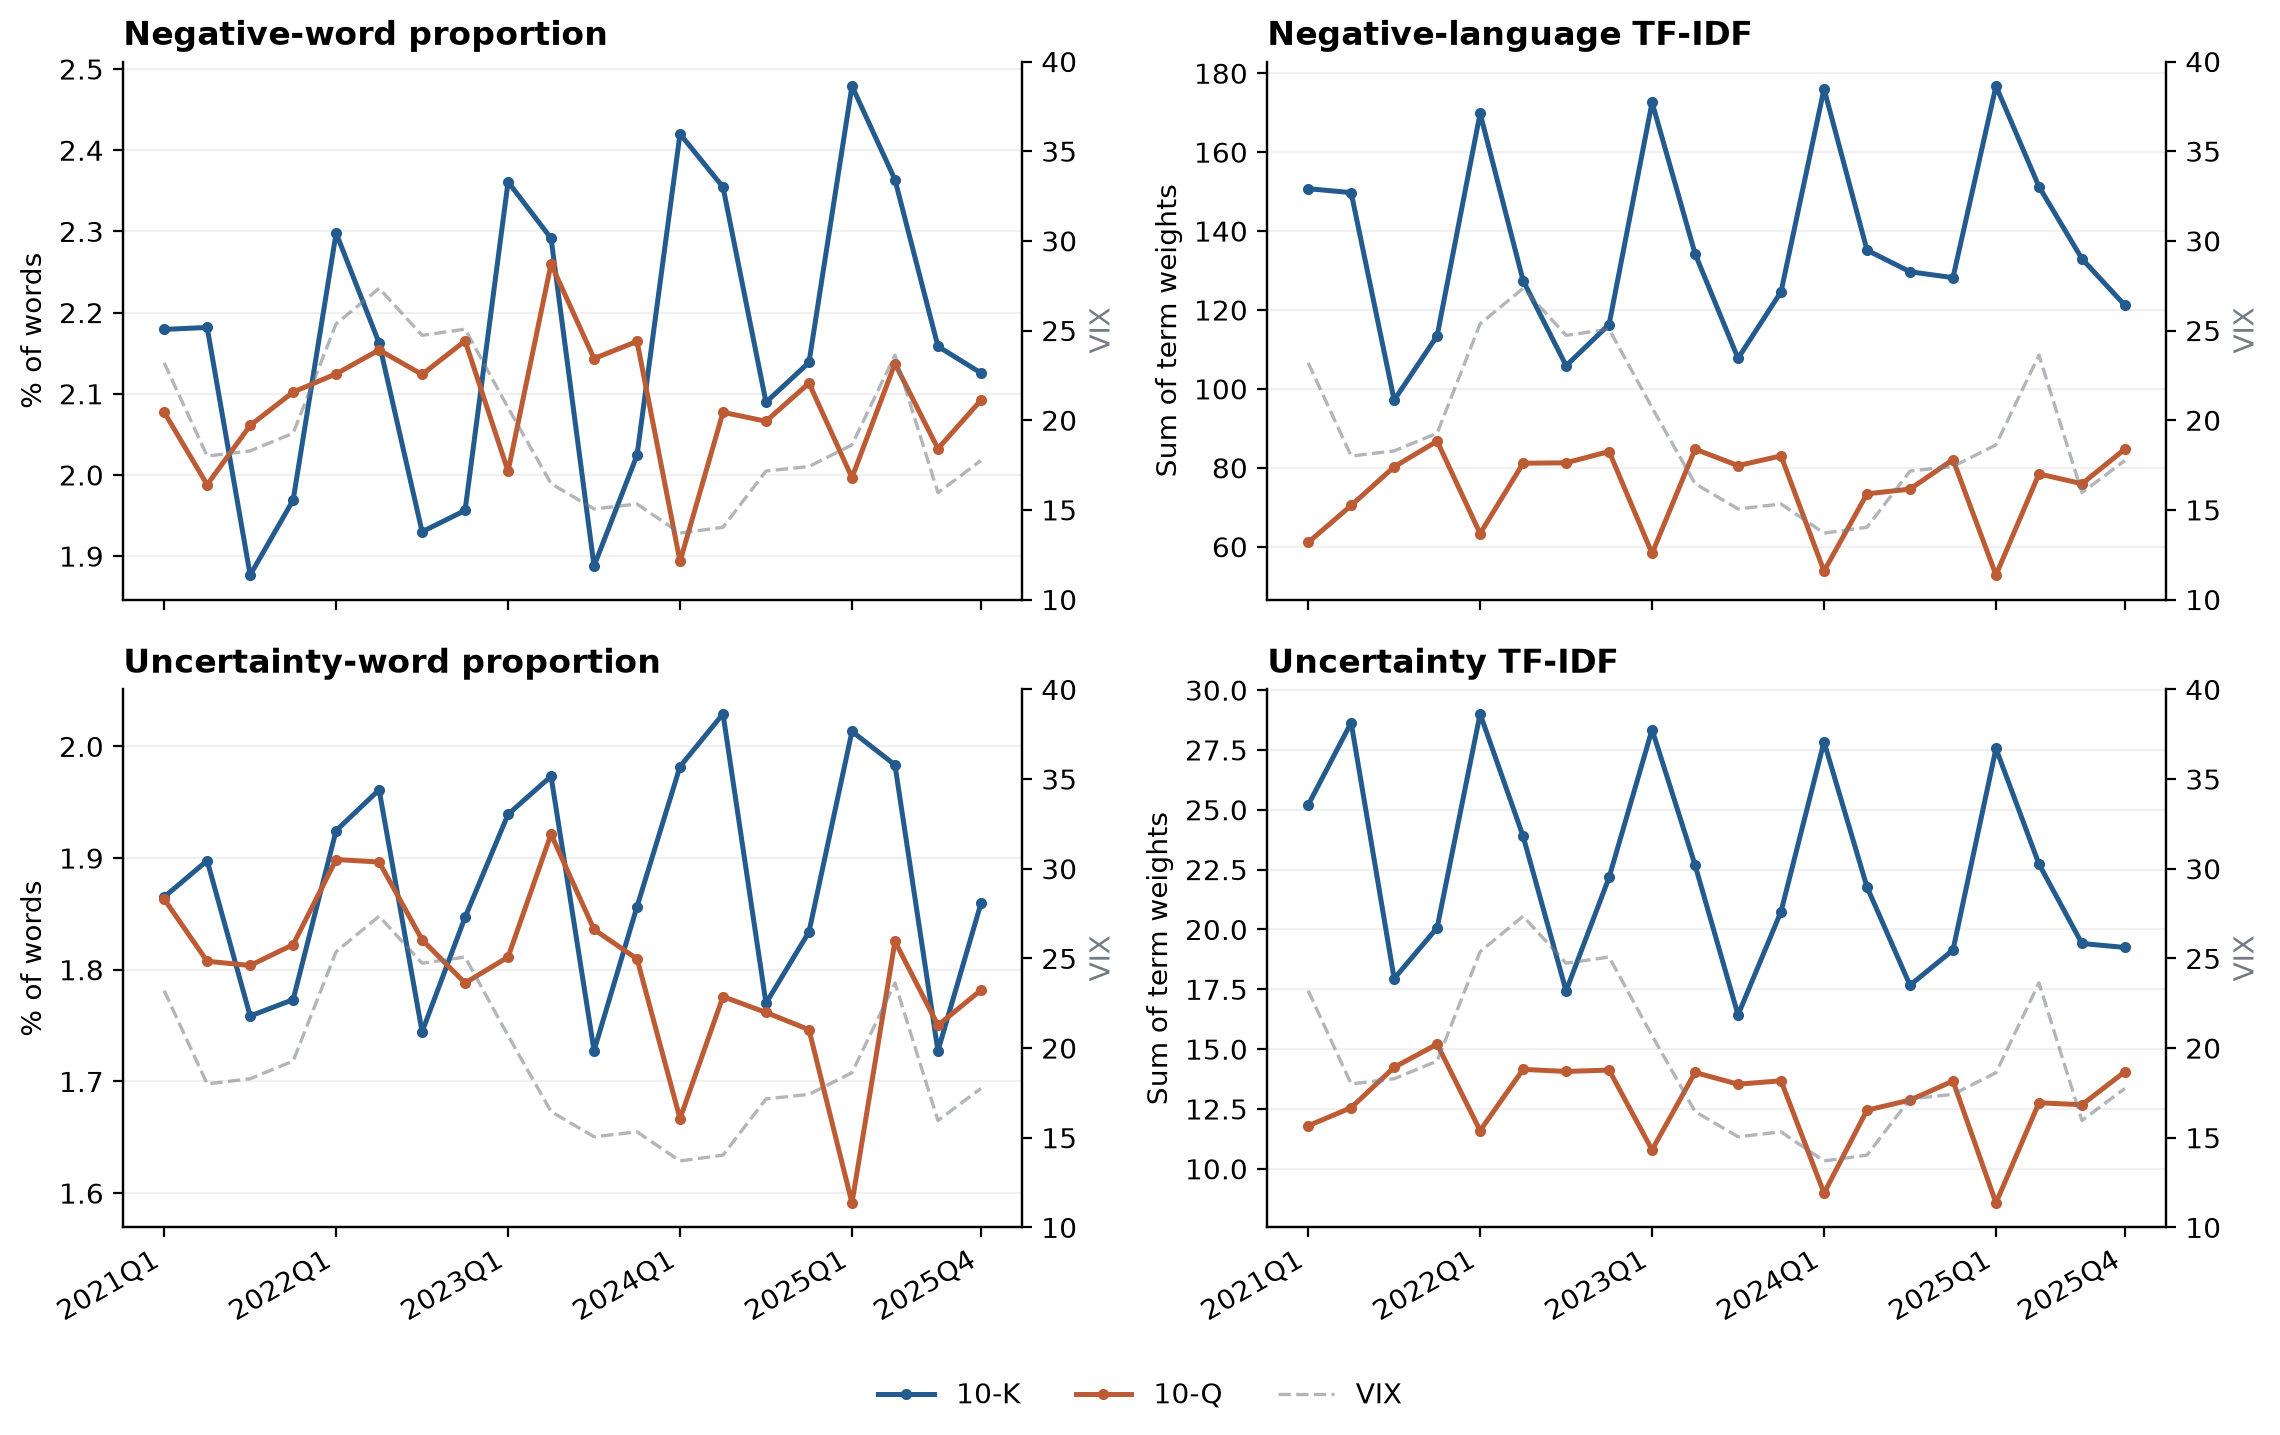

,Report type,quarter,negative_prop,negative_tfidf,uncertainty_prop,uncertainty_tfidf
0,10-K,2021Q1,0.0218,150.7358,0.0187,25.1988
1,10-K,2021Q2,0.0218,149.7388,0.0190,28.6402
2,10-K,2021Q3,0.0188,97.1490,0.0176,17.9474
3,10-K,2021Q4,0.0197,113.4558,0.0177,20.0683
4,10-K,2022Q1,0.0230,169.8267,0.0192,29.0065
5,10-K,2022Q2,0.0216,127.4327,0.0196,23.8935
6,10-K,2022Q3,0.0193,105.8822,0.0174,17.4322
7,10-K,2022Q4,0.0196,116.3141,0.0185,22.1734
8,10-K,2023Q1,0.0236,172.6010,0.0194,28.3509
9,10-K,2023Q2,0.0229,134.2594,0.0197,22.6914


In [8]:
display(Image(filename=str(RESULTS/'figure1.png')))
show_table(pd.read_csv(RESULTS/'quarterly_tone.csv'))

## Table 4 — Trend tests
The primary trend test includes issuer and quarter-of-year effects with issuer-clustered SEs. Aggregate OLS and Newey-West (four lags, finite-sample correction) t statistics are both reported. Proportional slopes are percentage points per year; TF-IDF slopes are term-weight units per year.

In [9]:
t4=pd.read_csv(RESULTS/'table4.csv')
show_table(t4[['form','measure','unit','aggregate_beta','aggregate_ols_t','aggregate_hac_t','within_beta','within_se','within_t','within_p','within_n','firms']])

,Report type,Language measure,unit,Overall slope,Ordinary OLS t statistic,Newey-West t statistic,Within-company slope,Within-company standard error,within_t,Within-company p-value,Company-quarter observations,Number of companies
0,10-K,Negative-word proportion,percentage points per year,0.0624,9.1481,12.8308,0.0631,0.0088,7.2116,0.0000,376,83
1,10-K,Negative-language TF-IDF,TF-IDF units per year,2.8919,3.2748,5.8500,2.6302,0.6959,3.7799,0.0003,376,83
2,10-K,Uncertainty-word proportion,percentage points per year,0.0179,3.5198,3.2045,0.0251,0.0049,5.1589,0.0000,376,83
3,10-K,Uncertainty TF-IDF,TF-IDF units per year,-0.1942,-1.0054,-1.5076,-0.0288,0.1118,-0.2581,0.7970,376,83
4,10-Q,Negative-word proportion,percentage points per year,-0.0089,-0.7670,-0.8122,-0.0069,0.0152,-0.4537,0.6512,1153,88
5,10-Q,Negative-language TF-IDF,TF-IDF units per year,-1.3448,-1.8499,-1.9882,-1.5188,1.2050,-1.2604,0.2109,1153,88
6,10-Q,Uncertainty-word proportion,percentage points per year,-0.0289,-2.8814,-3.0490,-0.0200,0.0101,-1.9734,0.0516,1153,88
7,10-Q,Uncertainty TF-IDF,TF-IDF units per year,-0.5164,-3.9690,-4.6413,-0.4824,0.1393,-3.4637,0.0008,1153,88


## Table 5 — Uncertainty and next-quarter volatility
The outcome is log annualized volatility on [+4,+63]; pre-volatility uses [-60,-6]. Both models include log size, log average dollar volume, prior SPY excess return, a 10-K indicator, company effects and calendar-quarter effects. The second adds log prior volatility. Both language measures remain continuous. Reported proportional coefficients are per 1 percentage-point increase; reported TF-IDF coefficients are per 1 unit. Internal standardization is rescaled back to these units and does not change fitted values, t-statistics or p-values.

In [10]:
t5=pd.read_csv(RESULTS/'table5.csv')
t5['Reported unit']=t5.measure.map(lambda x:'per 1 percentage point' if x.endswith('_prop') else 'per 1 TF-IDF unit')
t5['unit_scale']=t5.apply(lambda r:.01/r.score_sd if r.measure.endswith('_prop') else 1/r.score_sd,axis=1)
for col in ['beta','se','ci_low','ci_high']:
    t5[col]=t5[col]*t5.unit_scale
show_table(t5[['measure','Reported unit','control_set','formula','beta','se','t','p','ci_low','ci_high','n','firms','corpus']])
assert t5.groupby('measure').corpus.nunique().eq(1).all()
c=pd.read_csv(RESULTS/'all_regression_coefficients.csv')

,Language measure,Reported unit,Controls,Regression equation,Estimated coefficient,Standard error,t statistic,p-value (zero coefficient),95% confidence interval: lower,95% confidence interval: upper,Observations,Number of companies,corpus
0,Uncertainty-word proportion,per 1 percentage point,Without prior volatility,log_post_vol ~ score_z + log_market_value + lo...,0.0229,0.0299,0.7652,0.4462,-0.0366,0.0824,1536,91,089a63f8f2318a3d
1,Uncertainty-word proportion,per 1 percentage point,With prior volatility,log_post_vol ~ score_z + log_market_value + lo...,0.0005,0.0250,0.0202,0.9839,-0.0492,0.0502,1536,91,089a63f8f2318a3d
2,Uncertainty TF-IDF,per 1 TF-IDF unit,Without prior volatility,log_post_vol ~ score_z + log_market_value + lo...,0.0035,0.0027,1.3105,0.1934,-0.0018,0.0089,1536,91,089a63f8f2318a3d
3,Uncertainty TF-IDF,per 1 TF-IDF unit,With prior volatility,log_post_vol ~ score_z + log_market_value + lo...,0.0014,0.0019,0.7698,0.4434,-0.0023,0.0051,1536,91,089a63f8f2318a3d


## Table 6 — Sentiment and filing-period excess returns
The outcome is stock minus SPY buy-and-hold return over [0,+3], in percentage points. Proportion coefficients are per 1 percentage-point increase and TF-IDF coefficients per 1 unit. The model includes the full required control and fixed-effect set. The minimum detectable effect is an approximate 80%-power precision diagnostic, not observed power.

In [11]:
t6=pd.read_csv(RESULTS/'table6.csv')
t6['Reported unit']=t6.measure.map(lambda x:'per 1 percentage point' if x.endswith('_prop') else 'per 1 TF-IDF unit')
t6['unit_scale']=t6.apply(lambda r:.01/r.score_sd if r.measure.endswith('_prop') else 1/r.score_sd,axis=1)
for col in ['beta','se','ci_low','ci_high','mde80']:
    t6[col]=t6[col]*t6.unit_scale
show_table(t6[['measure','Reported unit','control_set','formula','beta','se','t','p','ci_low','ci_high','mde80','n','firms']])

,Language measure,Reported unit,Controls,Regression equation,Estimated coefficient,Standard error,t statistic,p-value (zero coefficient),95% confidence interval: lower,95% confidence interval: upper,Approximate detectable effect (80% power),Observations,Number of companies
0,Negative-word proportion,per 1 percentage point,With controls,excess_return ~ score_z + log_market_value + l...,-0.8146,0.7062,-1.1535,0.2518,-2.2177,0.5884,1.9974,1536,91
1,Negative-language TF-IDF,per 1 TF-IDF unit,With controls,excess_return ~ score_z + log_market_value + l...,-0.0118,0.0099,-1.1846,0.2393,-0.0315,0.0080,0.0281,1536,91


## Form and benchmark checks
Table 5 is re-estimated separately for 10-K and 10-Q samples, with sample-specific IDF. The return model is also estimated against ARKK to disclose benchmark sensitivity.

In [12]:
models=pd.read_csv(RESULTS/'all_outcome_models.csv')
show_table(models[['outcome','variant','measure','control_set','formula','beta','se','p','n','corpus']])

,outcome,variant,Language measure,Controls,Regression equation,Estimated coefficient,Standard error,p-value (zero coefficient),Observations,corpus
0,volatility,pooled,Uncertainty-word proportion,Without prior volatility,log_post_vol ~ score_z + log_market_value + lo...,0.0119,0.0156,0.4462,1536,089a63f8f2318a3d
1,volatility,pooled,Uncertainty-word proportion,With prior volatility,log_post_vol ~ score_z + log_market_value + lo...,0.0003,0.0130,0.9839,1536,089a63f8f2318a3d
2,volatility,pooled,Uncertainty TF-IDF,Without prior volatility,log_post_vol ~ score_z + log_market_value + lo...,0.0336,0.0257,0.1934,1536,089a63f8f2318a3d
3,volatility,pooled,Uncertainty TF-IDF,With prior volatility,log_post_vol ~ score_z + log_market_value + lo...,0.0136,0.0176,0.4434,1536,089a63f8f2318a3d
4,volatility,10-K,Uncertainty-word proportion,Without prior volatility,log_post_vol ~ score_z + log_market_value + lo...,-0.0303,0.1319,0.8189,381,d61e9612e85dccfa
5,volatility,10-K,Uncertainty-word proportion,With prior volatility,log_post_vol ~ score_z + log_market_value + lo...,-0.0319,0.1231,0.7962,381,d61e9612e85dccfa
6,volatility,10-K,Uncertainty TF-IDF,Without prior volatility,log_post_vol ~ score_z + log_market_value + lo...,0.2257,0.1193,0.0619,381,d61e9612e85dccfa
7,volatility,10-K,Uncertainty TF-IDF,With prior volatility,log_post_vol ~ score_z + log_market_value + lo...,0.1941,0.0936,0.0411,381,d61e9612e85dccfa
8,volatility,10-Q,Uncertainty-word proportion,Without prior volatility,log_post_vol ~ score_z + log_market_value + lo...,0.0463,0.0320,0.1505,1155,bfef4b59be42fa86
9,volatility,10-Q,Uncertainty-word proportion,With prior volatility,log_post_vol ~ score_z + log_market_value + lo...,0.0079,0.0214,0.7139,1155,bfef4b59be42fa86


## Interpretation and limitations
Annual-report negative language rises within issuers under both weighting schemes; uncertainty trends differ by form and weight. The pre-volatility control attenuates the uncertainty coefficient, and neither remaining pooled estimate is precise, so a robust incremental volatility relationship is not established. The four-day return test is imprecise. These are different tests with different evidence; a blanket claim that the sample is too small is not warranted.

The 2026 holdings snapshot creates survivorship/selection bias. It does not reveal former holdings that disappeared. Correct acceptance times and contemporaneous share counts do not cure that selection. Further limits include full-corpus scoring, 20 aggregate quarters, daily timing, and multi-class valuation approximations. The next improvement is a historical holdings universe followed by a held-out forecasting evaluation.

See the short PDF report for the test-by-test discussion and `AI_USE.md` for the authorship disclosure.

## Plain-language table guide
A score is the measured amount of uncertainty or negative language. Outcome tables report proportions per 1 percentage point and TF-IDF per 1 unit. A score p-value tests a zero score coefficient. Parentheses in the PDF contain company-clustered standard errors. Log means natural logarithm. P25/P75 are percentiles. Internal variable `score_z` means the standardized language score named by that model. The intercept is its fitted baseline.

# Analysis choices beyond the assignment text

The September 7 instructor update now fixes the filters, event windows and
control variables. The analysis follows those requirements directly.

The remaining implementation choices are limited:

| Location | Choice beyond or within an ambiguity in the assignment |
|---|---|
| Text parsing | Preserve visible inline-XBRL content and remove a table when digits exceed 15% of its non-space characters. Keep the starter uppercase tokenizer; do not stem or remove stopwords. |
| Duplicate securities | Treat filings as issuer-level documents and retain GOOGL when the same Alphabet filing appears under GOOG and GOOGL. |
| Dollar volume | Use the mean daily price times volume over trading days [-60,-6], then take its natural logarithm. |
| TF-IDF | Recompute document frequency on the exact corpus used by each pooled or form-specific regression. Models standardize each language score internally; report coefficients per 1 proportion percentage point or per 1 TF-IDF unit. |
| Inference | Use four Newey-West lags for the 20-quarter aggregate trends and company-clustered standard errors for repeated filing observations. |
| Return precision | Report an approximate 80%-power minimum detectable effect, `(cluster-t critical + 0.842) × clustered SE`. |
| Benchmark check | Re-estimate Table 6 using ARKK rather than SPY. |
| Q1/Q2 case evidence | Compare uncertainty-containing sentences (at least 12 tokens) in successive PayPal annual Risk Factors sections; describe the selected filing's observed return and volatility. |

No shell-company exclusion or other sample filter is added beyond the updated
rules; the required $3 cutoff is applied. No optional size-only or turnover
specification is added. The submitted PDF labels Q1-Q6 and reports all models
produced by the main analysis pipeline.
